# 01 · Overall performance tables

**Does AIM actually improve prediction performance, and does that change when
the encoder is pretrained?**

Mean Rank and Δm% for STL / LS / PCGrad / AIM-Scalar / AIM-Matrix, crossed with
both backbones. Reads `history.json` at the epoch `train.py` checkpointed — no
torch, no measurement.

Edit `TAG` to switch task set.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
import common as C
C.apply_style()
print("results trees:")
for b, d in C.RESULTS.items():
    for tag, p in d.items():
        print(f"  {b:9s} {tag:7s} {'OK ' if p.is_dir() else 'MISSING'} {p}")

results trees:
  Uni-Mol   2task   OK  E:\Projects\Results\Unimol\results_2task
  Uni-Mol   11task  OK  E:\Projects\Results\Unimol\results_11task
  GNN       2task   OK  E:\Projects\Results\GNN\result_2task
  GNN       11task  OK  E:\Projects\Results\GNN\result_11task


In [2]:
TAG = "11task"          # "2task" or "11task"
BACKBONES = ["Uni-Mol", "GNN"]

runs = {b: C.load_runs(b, TAG) for b in BACKBONES}
tasks = runs[BACKBONES[0]]["tasks"]
print(TAG, "->", len(tasks), "tasks:", ", ".join(tasks))
for b in BACKBONES:
    print(f"  {b:9s} methods={list(runs[b]['mtl'])}  STL tasks={len(runs[b]['stl'])}")

11task -> 11 tasks: mu, alpha, eps_HOMO, eps_LUMO, R2, zpve, U0, U, H, G, Cv
  Uni-Mol   methods=['LS', 'PCGrad', 'AIM-Scalar', 'AIM-Matrix']  STL tasks=11
  GNN       methods=['LS', 'PCGrad', 'AIM-Scalar', 'AIM-Matrix']  STL tasks=11


## Build the grid

One row per method, one column block per backbone.

In [6]:
rows = [["Method"] + [f"{b} {c}" for b in BACKBONES for c in ("dm%", "MR", "MR+STL")]]

summary = {}
for b in BACKBONES:
    sub = {m: {t: v[t] for t in tasks if t in v} for m, v in runs[b]["mtl"].items()}
    stl = {t: runs[b]["stl"][t] for t in tasks if t in runs[b]["stl"]}
    complete = len(stl) == len(tasks)
    summary[b] = dict(
        mr=C.mean_rank(sub),
        mr_all=C.mean_rank({**sub, "STL": stl}) if complete else {},
        dm=C.delta_m_percent(sub, stl) if complete else {},
    )

def cell(v, nd=2):
    return "--" if v is None or (isinstance(v, float) and np.isnan(v)) else f"{v:.{nd}f}"

rows.append(["STL"] + sum([["ref", "--", cell(summary[b]["mr_all"].get("STL"))]
                           for b in BACKBONES], []))
for m in C.METHODS:
    r = [m]
    for b in BACKBONES:
        s = summary[b]
        star = "*" if s["mr"] and m == min(s["mr"], key=s["mr"].get) else ""
        r += [cell(s["dm"].get(m), 1), cell(s["mr"].get(m)) + star,
              cell(s["mr_all"].get(m))]
    rows.append(r)

for r in rows:
    print("  ".join(f"{c:>14s}" if i else f"{c:<12s}" for i, c in enumerate(r)))

Method           Uni-Mol dm%      Uni-Mol MR  Uni-Mol MR+STL         GNN dm%          GNN MR      GNN MR+STL
STL                      ref              --            3.18             ref              --            1.00
LS                      19.2            2.45            3.00           232.2            2.73            3.73
PCGrad                  11.2           1.64*            2.00           256.4            3.45            4.45
AIM-Scalar              21.5            3.55            4.00           174.6           1.64*            2.64
AIM-Matrix              10.2            2.36            2.82           173.5            2.18            3.18


In [8]:
rows

[['Method',
  'Uni-Mol dm%',
  'Uni-Mol MR',
  'Uni-Mol MR+STL',
  'GNN dm%',
  'GNN MR',
  'GNN MR+STL'],
 ['STL', 'ref', '--', '3.18', 'ref', '--', '1.00'],
 ['LS', '19.2', '2.45', '3.00', '232.2', '2.73', '3.73'],
 ['PCGrad', '11.2', '1.64*', '2.00', '256.4', '3.45', '4.45'],
 ['AIM-Scalar', '21.5', '3.55', '4.00', '174.6', '1.64*', '2.64'],
 ['AIM-Matrix', '10.2', '2.36', '2.82', '173.5', '2.18', '3.18']]

Plot

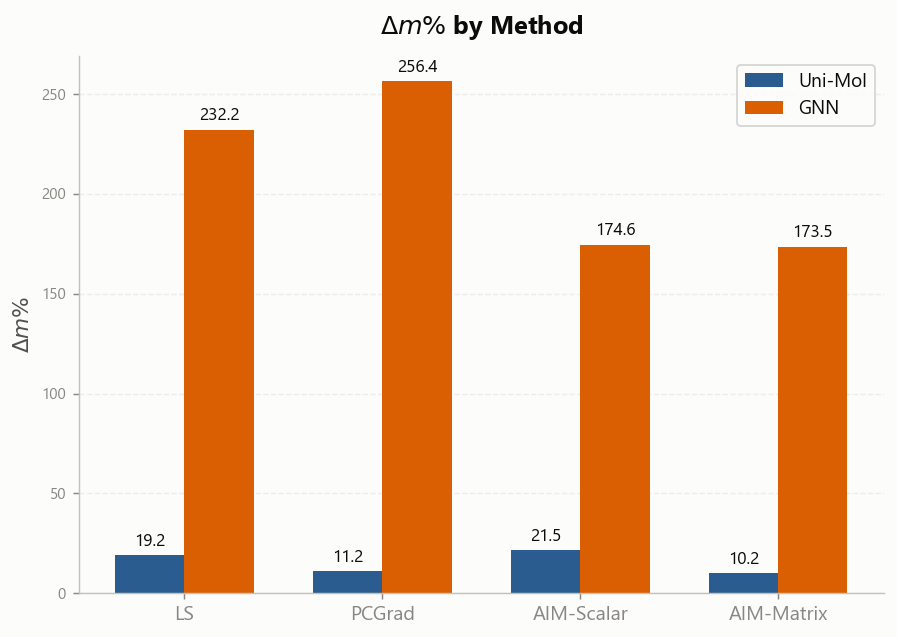

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data
data = {
    "Method": ["LS", "PCGrad", "AIM-Scalar", "AIM-Matrix"],
    "Uni-Mol dm%": [19.2, 11.2, 21.5, 10.2],
    "GNN dm%": [232.2, 256.4, 174.6, 173.5],
}
df = pd.DataFrame(data)

methods = df["Method"].tolist()
x = np.arange(len(methods))
width = 0.35

# Figure setup
fig, ax = plt.subplots(figsize=(7, 5))

# Bars
bars_um = ax.bar(
    x - width / 2,
    df["Uni-Mol dm%"],
    width,
    label="Uni-Mol",
    color="#2b5c8f",
)
bars_gnn = ax.bar(
    x + width / 2,
    df["GNN dm%"],
    width,
    label="GNN",
    color="#d95f02",
)

# Formatting
ax.set_title(r"$\Delta m\%$ by Method", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel(r"$\Delta m\%$", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend(frameon=True, fontsize=10.5)

# Value labels
ax.bar_label(bars_um, fmt="%.1f", padding=3, fontsize=9.5)
ax.bar_label(bars_gnn, fmt="%.1f", padding=3, fontsize=9.5)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

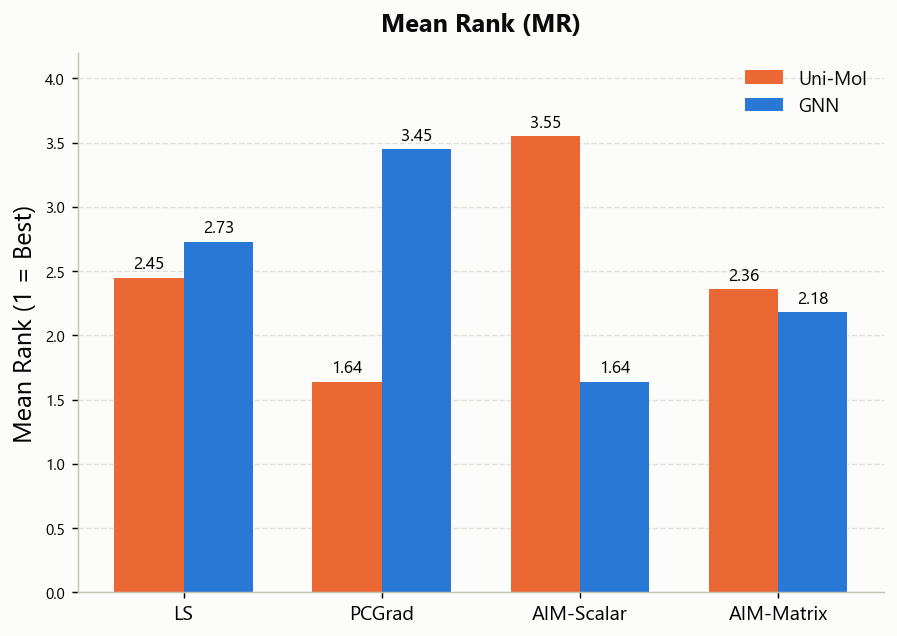

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
GNN, UNI = "#2a78d6", "#eb6834"
# Data
data = {
    "Method": ["LS", "PCGrad", "AIM-Scalar", "AIM-Matrix"],
    "Uni-Mol MR": [2.45, 1.64, 3.55, 2.36],
    "GNN MR": [2.73, 3.45, 1.64, 2.18],
}
df = pd.DataFrame(data)

methods = df["Method"].tolist()
x = np.arange(len(methods))
width = 0.35

# Figure setup
fig, ax = plt.subplots(figsize=(7, 5))

# Bars
bars_um = ax.bar(
    x - width / 2,
    df["Uni-Mol MR"],
    width,
    label="Uni-Mol",
    color=UNI
)
bars_gnn = ax.bar(
    x + width / 2,
    df["GNN MR"],
    width,
    label="GNN",
    color=GNN,
)

# Formatting
ax.set_title("Mean Rank (MR)", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Mean Rank (1 = Best)", fontsize=14, color="black")
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 4.2)
ax.grid(axis="y", linestyle="--")
ax.set_axisbelow(True)
ax.legend( fontsize=10.5)

# Bar value labels in black
ax.bar_label(bars_um, fmt="%.2f", padding=3, fontsize=9.5, color="black")
ax.bar_label(bars_gnn, fmt="%.2f", padding=3, fontsize=9.5, color="black")

ax.tick_params(axis="both", colors="black", which="both")

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Render as a PNG

Hairlines only — no boxed grid, no zebra striping. The best MTL method per backbone is picked out in orange.

saved E:\Projects\aim_mtl\notebooks\figures\11task\overall_11task.png


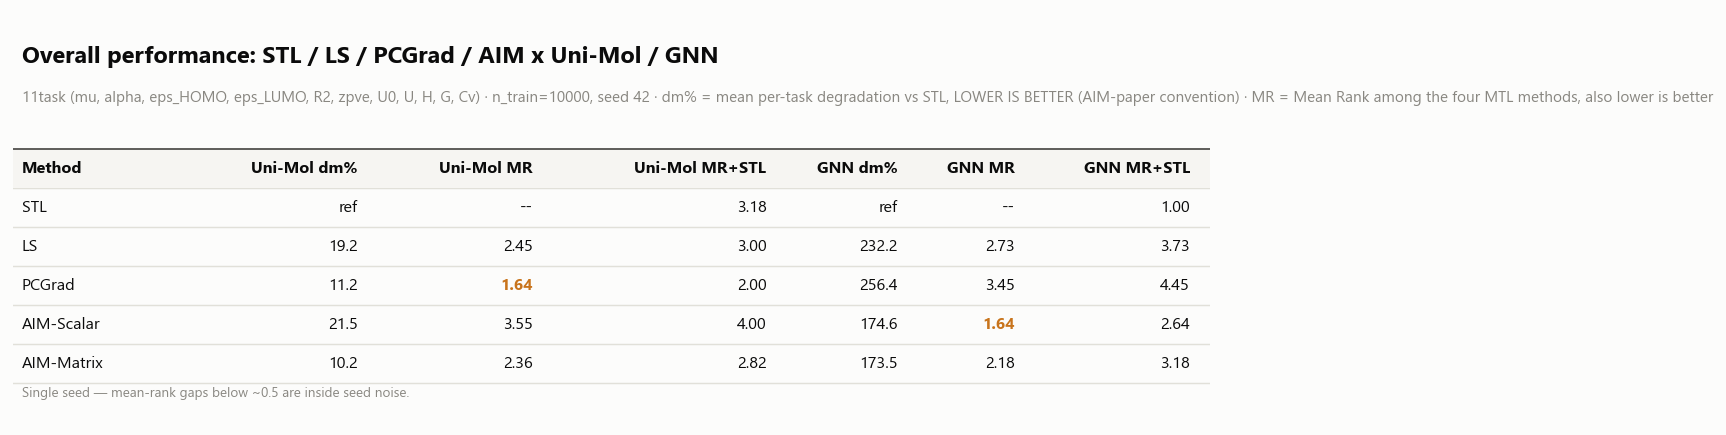

In [7]:
def table_png(rows, title, subtitle, note=""):
    n_r, n_c = len(rows), len(rows[0])
    widths = [max(len(r[i]) for r in rows) + 2 for i in range(n_c)]
    total = sum(widths)
    row_h, head_h = 0.30, 1.05
    fig_h = head_h + row_h * n_r + 0.3
    fig = plt.figure(figsize=(max(6, 0.105 * total + .6), fig_h), facecolor=C.SURFACE)
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_axis_off()
    ax.set_xlim(0, total); ax.set_ylim(0, fig_h)
    xs, x = [], 0.6
    for w in widths:
        xs.append(x); x += w
    top = fig_h - head_h
    fig.text(.6 / total, (fig_h - .34) / fig_h, title, ha="left", va="center",
             fontsize=13, fontweight="bold", color=C.INK)
    fig.text(.6 / total, (fig_h - .66) / fig_h, subtitle, ha="left", va="center",
             fontsize=8.5, color=C.MUTED)
    for ri, row in enumerate(rows):
        y = top - row_h * (ri + .5)
        if ri == 0:
            ax.add_patch(plt.Rectangle((0, y - row_h / 2), total, row_h,
                                       facecolor=C.BAND, edgecolor="none"))
        for ci, cl in enumerate(row):
            star = cl.endswith("*")
            ax.text(xs[ci] + (0 if ci == 0 else widths[ci] - 2), y, cl.rstrip("*"),
                    ha="left" if ci == 0 else "right", va="center", fontsize=9,
                    color=C.ACCENT if star else C.INK,
                    fontweight="bold" if (ri == 0 or star) else "normal")
        ax.plot([0, total], [y - row_h / 2] * 2, color=C.GRID, lw=.8, zorder=0)
    ax.plot([0, total], [top] * 2, color=C.SECONDARY, lw=1.0)
    if note:
        ax.text(.6, .22, note, ha="left", va="center", fontsize=7.5, color=C.MUTED)
    return fig

fig = table_png(
    rows,
    "Overall performance: STL / LS / PCGrad / AIM x Uni-Mol / GNN",
    f"{TAG} ({', '.join(tasks)}) · n_train={C.N_TRAIN}, seed {C.SEED} · "
    "dm% = mean per-task degradation vs STL, LOWER IS BETTER (AIM-paper convention) · MR = Mean Rank among the four MTL methods, also lower is better",
    "Single seed — mean-rank gaps below ~0.5 are inside seed noise.")
C.save(fig, f"overall_{TAG}", TAG); plt.show()

## Per-task MAE table

saved E:\Projects\aim_mtl\notebooks\figures\11task\per_task_11task.png


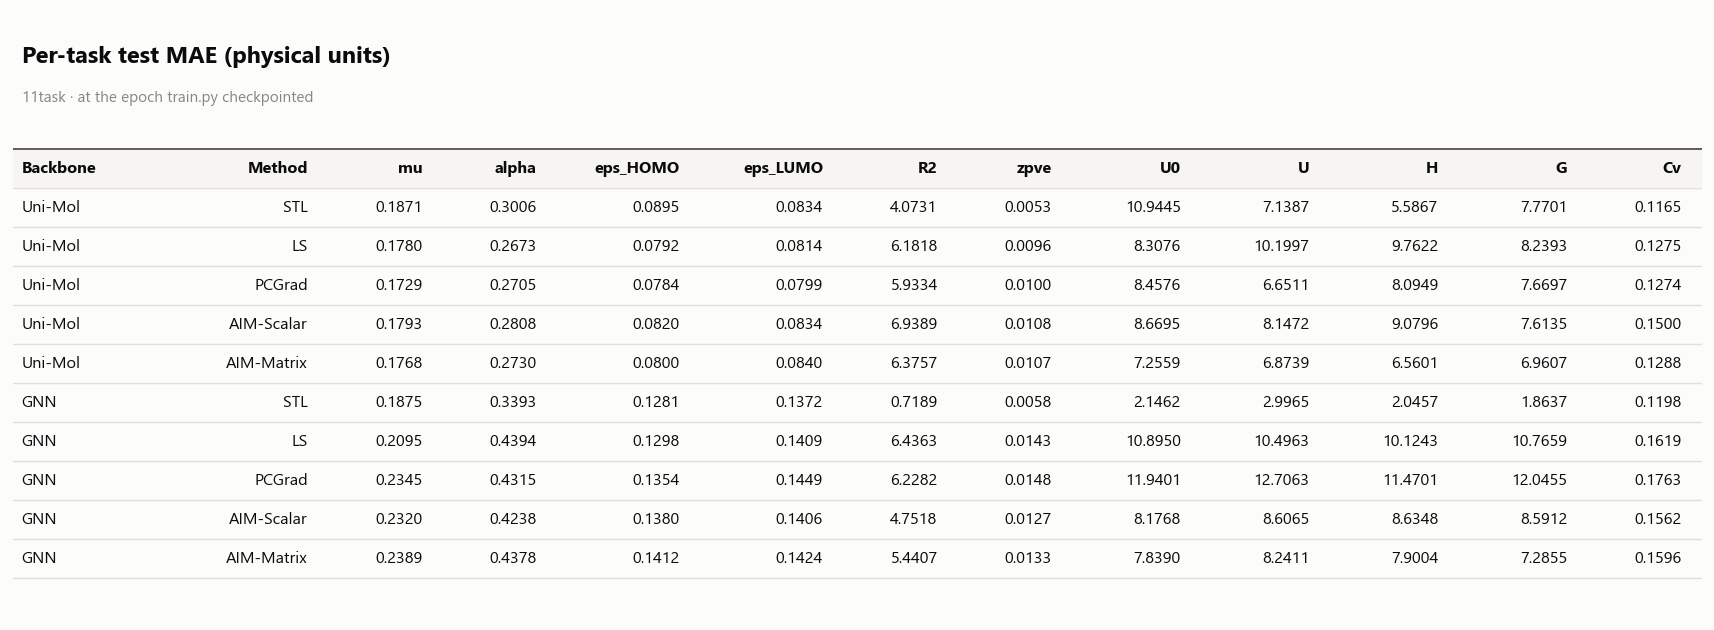

In [5]:
pt = [["Backbone", "Method"] + tasks]
for b in BACKBONES:
    if runs[b]["stl"]:
        pt.append([b, "STL"] + [f"{runs[b]['stl'].get(t, float('nan')):.4f}" for t in tasks])
    for m in C.METHODS:
        if m in runs[b]["mtl"]:
            pt.append([b, m] + [f"{runs[b]['mtl'][m].get(t, float('nan')):.4f}" for t in tasks])

fig = table_png(pt, "Per-task test MAE (physical units)",
                f"{TAG} · at the epoch train.py checkpointed")
C.save(fig, f"per_task_{TAG}", TAG); plt.show()